# QSAR: Molecular Property Prediction

## Learning Objectives

By the end of this notebook you will be able to:

- Explain the **QSAR (Quantitative Structure–Activity Relationship)** framework and its role in computational chemistry and drug discovery.
- Describe how molecules are represented numerically via **molecular descriptors** and **fingerprints**.
- Apply **regularised regression**, **random forests**, and **gradient boosting** to a molecular property prediction task.
- Evaluate QSAR models using chemistry-appropriate metrics and cross-validation strategies.
- Understand the concept of **applicability domain** and why it matters for real-world deployment.

## Prerequisites

- **Notebooks 01–03 of this module:** regularisation (Ridge/Lasso), tree-based methods (Random Forest, Gradient Boosting), and Gaussian processes.
- **Module 06:** Simple and multiple linear regression.
- Basic familiarity with pandas DataFrames and scikit-learn pipelines.

## Setup

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system("pip install -q scikit-learn")

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import (
    apply_style,
    PALETTE,
    SALMON,
    EMERALD,
    PERIWINKLE,
    CYAN,
    ORCHID,
    GOLD,
)

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  \u2713 media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. What is QSAR?

### 1.1 Historical Roots

The idea that the **structure** of a chemical compound determines its **properties** is one of the oldest principles in chemistry. In 1868, Alexander Crum Brown and Thomas Fraser published one of the earliest observations that biological activity could be related to chemical constitution. But the modern quantitative framework traces back to **Corwin Hansch and Toshio Fujita (1964)**, who proposed that biological activity could be modelled as a linear function of physicochemical properties:

$$
\log\left(\frac{1}{C}\right) = a\,\pi + b\,\sigma + c\,E_s + d
$$

where $C$ is the molar concentration producing a standard biological response, $\pi$ is a hydrophobicity parameter, $\sigma$ is an electronic (Hammett) constant, and $E_s$ is a steric parameter. The coefficients $a, b, c, d$ are fitted by regression.

This is nothing more than **multiple linear regression** — the same technique we studied in Module 06 — applied to chemical data. The insight was not mathematical but *scientific*: that molecular structure can be decomposed into quantifiable features that predict macroscopic behaviour.

### 1.2 The Central Idea

**QSAR (Quantitative Structure–Activity Relationship)** is the general framework for building statistical models that relate molecular structure to a measurable property or activity:

$$
\text{Property} = f(\text{molecular descriptors}) + \varepsilon
$$

The function $f$ can be anything from a linear model to a deep neural network. The key steps are:

1. **Molecule** → Choose a structural representation (SMILES, graph, 3D coordinates).
2. **Representation → Descriptors** → Compute numerical features (molecular weight, polarity, shape, etc.).
3. **Descriptors → Model** → Train a supervised learning model to predict the target property.
4. **Model → Prediction** → Apply to new molecules.

This is precisely the supervised regression pipeline we have been studying, with the domain-specific twist that our "features" come from chemistry.

### 1.3 Real-World Applications

QSAR models are used daily across the chemical sciences:

| Domain                      | Predicted Property                                                                 | Impact                                            |
|-----------------------------|------------------------------------------------------------------------------------|---------------------------------------------------|
| **Drug discovery**          | Binding affinity, toxicity, ADME (absorption, distribution, metabolism, excretion) | Prioritise which molecules to synthesise and test |
| **Environmental chemistry** | Biodegradability, aquatic toxicity, bioaccumulation                                | Regulatory risk assessment (REACH, EPA)           |
| **Materials science**       | Melting point, solubility, conductivity, band gap                                  | Accelerate materials design                       |
| **Agrochemistry**           | Herbicide/pesticide activity                                                       | Reduce experimental screening costs               |

QSAR is one of the **oldest applications of machine learning**, predating the modern ML era by decades. When a pharmaceutical company screens millions of virtual compounds to find drug candidates, QSAR models are doing the heavy lifting. The statistical foundations — regularisation, cross-validation, uncertainty quantification — that we have built up throughout this course are exactly what makes these models trustworthy.

---

## 2. Molecular Representations

Before we can apply any ML model, we need to convert molecules into numbers. There are several levels of representation, each with different trade-offs between information content and computational cost.

### 2.1 SMILES Strings

**SMILES (Simplified Molecular Input Line Entry System)** is a compact linear text notation for molecular structures. Every atom, bond, ring, and branch is encoded in a string:

| Molecule    | SMILES                       | Notes                                              |
|-------------|------------------------------|----------------------------------------------------|
| Ethanol     | `CCO`                        | Two carbons + oxygen                               |
| Acetic acid | `CC(=O)O`                    | Carbonyl written as `=O`                           |
| Benzene     | `c1ccccc1`                   | Lowercase = aromatic; `1...1` closes the ring      |
| Aspirin     | `CC(=O)Oc1ccccc1C(=O)O`      | An ester linking an acetyl group to salicylic acid |
| Caffeine    | `Cn1cnc2c1c(=O)n(c(=O)n2C)C` | Fused ring system with multiple nitrogens          |

SMILES strings are the *lingua franca* of cheminformatics — databases, file formats, and software all speak SMILES. However, a SMILES string is not directly usable as input to a regression model. We need to convert it into a fixed-length numerical vector.

### 2.2 Molecular Descriptors

**Molecular descriptors** are scalar numerical properties computed from a molecule's structure. They capture different aspects of molecular geometry, electronics, and topology. Some of the most commonly used descriptors include:

- **Molecular Weight (MW):** The sum of atomic masses. Heavier molecules tend to be less soluble and less permeable.
- **LogP (octanol–water partition coefficient):** Measures hydrophobicity — how much a molecule prefers oil-like environments over water. Formally:
  $$
  \log P = \log_{10}\!\left(\frac{[\text{solute}]_{\text{octanol}}}{[\text{solute}]_{\text{water}}}\right)
  $$
  High LogP $\Rightarrow$ hydrophobic ("greasy"); low LogP $\Rightarrow$ hydrophilic ("water-loving"). This is arguably the single most important descriptor in drug design.
- **Hydrogen Bond Donors (HBD):** Count of NH and OH groups. These form hydrogen bonds with water, increasing solubility.
- **Hydrogen Bond Acceptors (HBA):** Count of N and O atoms that can accept hydrogen bonds.
- **Topological Polar Surface Area (TPSA):** The surface area contributed by polar atoms (N, O, and their attached hydrogens). Correlates with membrane permeability.
- **Rotatable Bonds:** Count of single bonds that allow free rotation. Measures molecular flexibility.
- **Aromatic Rings:** Count of aromatic ring systems. Aromatic groups are planar and hydrophobic.

These descriptors are well-studied, interpretable, and cheap to compute. The famous **Lipinski Rule of Five** for drug-likeness is simply a set of thresholds on four descriptors: MW $\leq$ 500, LogP $\leq$ 5, HBD $\leq$ 5, HBA $\leq$ 10.

### 2.3 Molecular Fingerprints

**Molecular fingerprints** are high-dimensional binary (or count) vectors that encode the presence of specific substructural features. The most widely used type is the **Morgan fingerprint** (also called **ECFP — Extended-Connectivity Fingerprint**):

1. For each atom, enumerate all circular substructures (neighbourhoods) up to a given radius $r$.
2. Hash each substructure to an integer.
3. Fold these integers into a fixed-length bit vector (e.g., 1024 or 2048 bits).

The result is a sparse binary vector where each bit indicates the presence of a particular substructural pattern. Two molecules with similar fingerprints share many substructures and are likely to have similar properties — this is the **molecular similarity principle** that underpins all of QSAR.

### 2.4 Computing Descriptors in Practice

In practice, molecular descriptors and fingerprints are computed using **RDKit**, the open-source cheminformatics toolkit. The cell below shows a brief illustrative example. RDKit is *not* required for the rest of this notebook — we will work with a pre-computed descriptor dataset.

In [ ]:
# Illustrative RDKit example -- runs only if RDKit is installed.
# The rest of this notebook does NOT depend on RDKit.
try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, rdMolDescriptors

    examples = {
        "Ethanol": "CCO",
        "Aspirin": "CC(=O)Oc1ccccc1C(=O)O",
        "Caffeine": "Cn1cnc2c1c(=O)n(c(=O)n2C)C",
    }
    rows = []
    for name, smi in examples.items():
        mol = Chem.MolFromSmiles(smi)
        rows.append(
            {
                "Name": name,
                "SMILES": smi,
                "MW": round(Descriptors.MolWt(mol), 1),
                "LogP": round(Descriptors.MolLogP(mol), 2),
                "HBD": rdMolDescriptors.CalcNumHBD(mol),
                "HBA": rdMolDescriptors.CalcNumHBA(mol),
                "TPSA": round(Descriptors.TPSA(mol), 1),
            }
        )
    print(pd.DataFrame(rows).to_string(index=False))

except ImportError:
    print("RDKit not installed -- skipping illustrative example.")
    print("This is fine; the rest of the notebook uses a pre-computed dataset.")

    Name                     SMILES    MW  LogP  HBD  HBA  TPSA
 Ethanol                        CCO  46.1 -0.00    1    1  20.2
 Aspirin      CC(=O)Oc1ccccc1C(=O)O 180.2  1.31    1    3  63.6
Caffeine Cn1cnc2c1c(=O)n(c(=O)n2C)C 194.2 -1.03    0    3  61.8


---

## 3. The Solubility Prediction Task

### 3.1 Why Solubility?

**Aqueous solubility** — how well a compound dissolves in water — is one of the most critical properties in drug discovery. A drug that cannot dissolve in the aqueous environment of the gastrointestinal tract cannot be absorbed into the bloodstream, no matter how potent it is at its target. Estimates suggest that **up to 40% of drug candidates fail due to poor pharmacokinetic properties**, with solubility being a leading contributor.

Solubility is conventionally measured as $\log S$, the base-10 logarithm of the molar solubility:

$$
\log S = \log_{10}\!\left(\frac{\text{solubility in mol}}{\text{L}}\right)
$$

Typical values range from about $-8$ (practically insoluble) to $+1$ (highly soluble). Most drug-like molecules fall in the range $-6$ to $0$.

### 3.2 The Delaney (ESOL) Benchmark

The classic QSAR solubility benchmark was published by **John Delaney (2004)**, who compiled aqueous solubility data for 1,144 organic compounds and showed that a simple linear model using just four descriptors could achieve an RMSE of about 0.7 log units. This dataset, known as **ESOL (Estimated SOLubility)**, has become one of the most widely used benchmarks in molecular ML.

Delaney's original model was remarkably simple:

$$
\log S = 0.16 - 0.63\,\text{cLogP} - 0.0062\,\text{MW} + 0.066\,\text{RB} - 0.74\,\text{AP}
$$

where cLogP is the calculated LogP, MW is molecular weight, RB is the number of rotatable bonds, and AP is the aromatic proportion (fraction of heavy atoms that are aromatic). This teaches us something important: **for many QSAR problems, simple models with good descriptors go a long way**.

### 3.3 Generating a Realistic Synthetic Dataset

For pedagogical purposes, we generate a synthetic dataset that mimics the statistical structure of real QSAR solubility data. We create 1,000 "molecules", each described by 10 molecular descriptors, with a target variable $\log S$ that follows a physically plausible relationship.

The data generation process below is designed so that:

- Descriptor distributions match realistic ranges (e.g., molecular weight is right-skewed between 150 and 600, LogP is roughly normal centred around 2.5).
- Descriptors are **correlated** with each other, as they are in real chemical space (e.g., TPSA correlates with HBA and HBD; molecular weight correlates with number of heavy atoms).
- The target $\log S$ depends on descriptors in a way consistent with physical chemistry: solubility decreases with molecular weight and hydrophobicity (LogP), and increases with hydrogen-bonding capacity.

In [ ]:
# ── Generate a realistic synthetic QSAR dataset ──
n = 1000

# --- 1. Base descriptors with realistic distributions ---

# Number of heavy atoms (non-hydrogen): drives MW and other size descriptors
num_heavy = rng.integers(8, 45, size=n).astype(float)

# Molecular weight: roughly 14*num_heavy + noise (avg MW per heavy atom ~ 14 Da)
mol_weight = 12.0 * num_heavy + rng.normal(30, 15, size=n)
mol_weight = np.clip(mol_weight, 120, 700)

# LogP: hydrophobicity, weakly correlated with size
logp = 0.04 * num_heavy + rng.normal(0.5, 1.2, size=n)
logp = np.clip(logp, -2.0, 8.0)

# Hydrogen bond donors: Poisson distributed, weakly inversely correlated with LogP
hbd_rate = np.clip(2.0 - 0.15 * logp, 0.3, 4.0)
hbd = rng.poisson(hbd_rate).astype(float)
hbd = np.clip(hbd, 0, 8)

# Hydrogen bond acceptors: correlates with molecule size
hba_rate = 0.08 * num_heavy + rng.normal(1.0, 0.5, size=n)
hba_rate = np.clip(hba_rate, 0.5, 8.0)
hba = rng.poisson(hba_rate).astype(float)
hba = np.clip(hba, 0, 15)

# TPSA: correlated with HBD and HBA (each polar group contributes ~20 A^2)
tpsa = 20.0 * hbd + 9.0 * hba + rng.normal(5, 8, size=n)
tpsa = np.clip(tpsa, 0, 250)

# Number of rotatable bonds: correlates with molecular size
rot_bonds = rng.poisson(0.12 * num_heavy).astype(float)
rot_bonds = np.clip(rot_bonds, 0, 15)

# Number of rings and aromatic rings
num_rings = rng.poisson(0.06 * num_heavy + 0.5).astype(float)
num_rings = np.clip(num_rings, 0, 8)
arom_rings = np.minimum(num_rings, rng.poisson(0.7 * num_rings + 0.3).astype(float))
arom_rings = np.clip(arom_rings, 0, 6)

# Fraction of sp3 carbons: inversely related to aromaticity
frac_csp3 = np.clip(0.6 - 0.15 * arom_rings + rng.normal(0, 0.12, size=n), 0.0, 1.0)

# --- 2. Target variable: logS ---
# Physically motivated: solubility decreases with MW and LogP,
# increases with hydrogen bonding, has nonlinear and interaction terms.
logS = (
    0.5
    - 0.01 * mol_weight
    - 0.74 * logp
    + 0.30 * hbd
    + 0.18 * hba
    - 0.005 * tpsa
    + 0.07 * rot_bonds
    - 0.12 * arom_rings
    - 0.003 * mol_weight * logp / 5.0  # interaction: large + greasy -> very insoluble
    + 0.02 * frac_csp3 * mol_weight / 100.0  # sp3-rich molecules slightly more soluble
    + rng.normal(0, 0.45, size=n)  # measurement noise
)

# --- 3. Assemble DataFrame ---
df = pd.DataFrame(
    {
        "MolWeight": np.round(mol_weight, 1),
        "LogP": np.round(logp, 2),
        "HBD": hbd.astype(int),
        "HBA": hba.astype(int),
        "TPSA": np.round(tpsa, 1),
        "RotatableBonds": rot_bonds.astype(int),
        "AromaticRings": arom_rings.astype(int),
        "NumHeavyAtoms": num_heavy.astype(int),
        "NumRings": num_rings.astype(int),
        "FractionCSP3": np.round(frac_csp3, 3),
        "logS": np.round(logS, 3),
    }
)

feature_cols = [c for c in df.columns if c != "logS"]
print(f"Dataset shape: {df.shape}")
print(f"Features: {feature_cols}")
print(f"Target: logS (aqueous solubility, log mol/L)")

Dataset shape: (1000, 11)
Features: ['MolWeight', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotatableBonds', 'AromaticRings', 'NumHeavyAtoms', 'NumRings', 'FractionCSP3']
Target: logS (aqueous solubility, log mol/L)


Let us inspect the first few rows and summary statistics to verify the data looks realistic.

In [4]:
df.head(10)

,MolWeight,LogP,HBD,HBA,TPSA,RotatableBonds,AromaticRings,NumHeavyAtoms,NumRings,FractionCSP3,logS
0,183.5,1.62,3,0,72.5,1,2,11,2,0.239,-2.051
1,463.4,2.08,2,2,69.7,4,2,36,5,0.485,-6.006
2,422.7,2.18,1,3,53.6,2,5,32,5,0.000,-5.711
3,317.1,2.39,2,1,50.5,2,0,24,0,0.695,-3.488
4,315.4,0.49,1,2,43.9,7,0,24,1,0.676,-2.236
5,486.3,3.11,1,2,38.2,2,5,39,7,0.000,-6.738
6,168.5,-0.71,3,2,81.4,2,0,11,0,0.830,0.505
7,413.2,2.21,1,3,72.9,2,2,33,2,0.340,-5.442
8,220.0,1.31,1,4,62.5,0,2,15,2,0.091,-2.322
9,178.3,0.20,0,5,53.6,3,0,11,1,0.516,-0.732


In [5]:
df.describe().round(2)

,MolWeight,LogP,HBD,HBA,TPSA,RotatableBonds,AromaticRings,NumHeavyAtoms,NumRings,FractionCSP3,logS
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,343.28,1.44,1.70,3.12,67.23,3.14,1.43,26.12,2.08,0.39,-3.52
std,129.32,1.27,1.34,2.06,32.91,2.14,1.39,10.68,1.60,0.22,2.12
min,120.00,-2.00,0.00,0.00,0.00,0.00,0.00,8.00,0.00,0.00,-9.70
25%,227.75,0.64,1.00,1.00,43.35,1.00,0.00,17.00,1.00,0.23,-5.07
50%,347.45,1.48,1.00,3.00,64.05,3.00,1.00,26.00,2.00,0.42,-3.44
75%,454.05,2.24,2.00,4.00,87.62,4.00,2.00,36.00,3.00,0.56,-1.99
max,580.20,5.38,8.00,11.00,203.00,11.00,6.00,44.00,8.00,0.93,1.80


The distributions look reasonable: molecular weights span roughly 120–700 Da, LogP ranges from about $-2$ to 8, and $\log S$ spans approximately $-10$ to $+2$, consistent with real solubility data.

---

## 4. Exploratory Data Analysis

Before modelling, we explore the structure of the data. In QSAR, EDA serves two purposes: (1) verifying that descriptors have reasonable ranges and distributions, and (2) identifying the strongest univariate predictors, which informs feature selection and model interpretation.

### 4.1 Target Distribution

We begin with the distribution of $\log S$. A roughly normal (or at least unimodal and not too skewed) target distribution is reassuring — it means standard regression assumptions are not wildly violated.

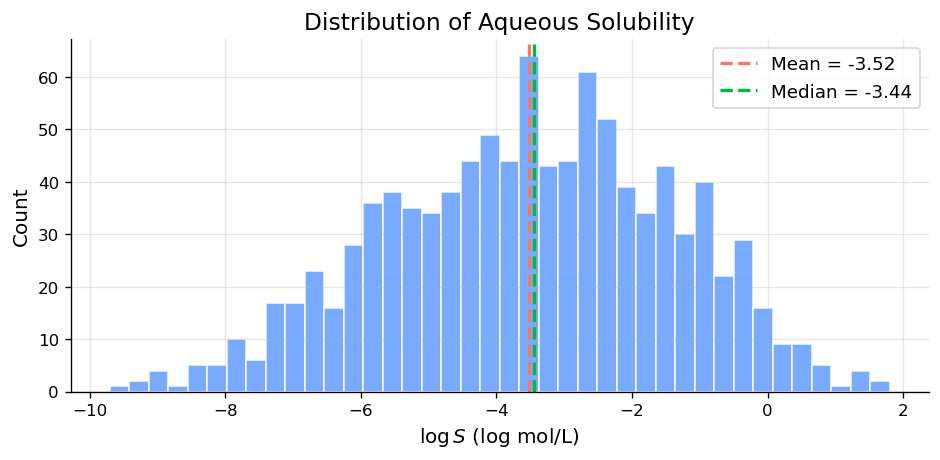

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["logS"], bins=40, color=PERIWINKLE, edgecolor="white", alpha=0.85)
ax.axvline(
    df["logS"].mean(),
    color=SALMON,
    ls="--",
    lw=2,
    label=f"Mean = {df['logS'].mean():.2f}",
)
ax.axvline(
    df["logS"].median(),
    color=EMERALD,
    ls="--",
    lw=2,
    label=f"Median = {df['logS'].median():.2f}",
)
ax.set_xlabel(r"$\log S$ (log mol/L)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Aqueous Solubility")
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Correlation Structure

The heatmap below shows Pearson correlations among all descriptors and the target. We expect to see:

- **MolWeight** and **NumHeavyAtoms** strongly correlated (both measure molecular size).
- **TPSA** correlated with **HBD** and **HBA** (by construction, TPSA is driven by polar atoms).
- **LogP** and **MolWeight** negatively correlated with **logS** (larger, greasier molecules are less soluble).

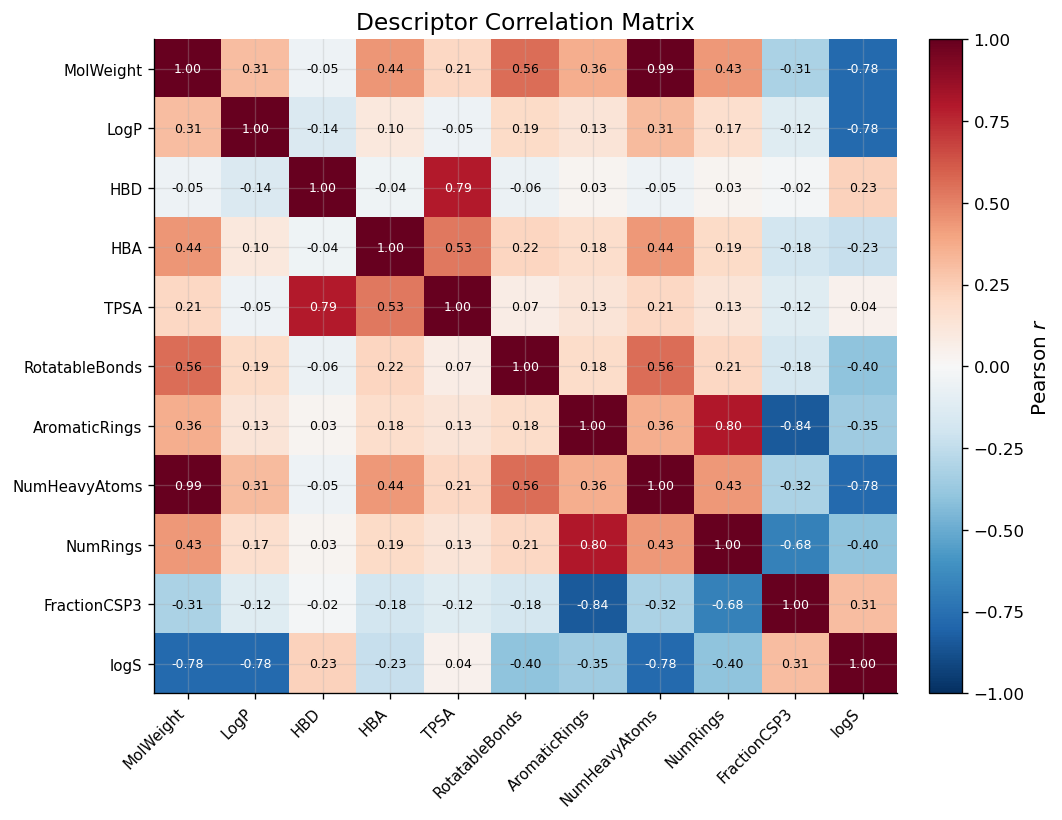

In [ ]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)

# Annotate cells
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.values[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7.5, color=color)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson $r$")
ax.set_title("Descriptor Correlation Matrix")
plt.tight_layout()
plt.show()

### 4.3 Key Descriptor–Solubility Relationships

The scatter plots below show the four descriptors with the strongest univariate correlation to $\log S$. In real QSAR work, this step guides descriptor selection and helps identify nonlinearities that simple linear models might miss.

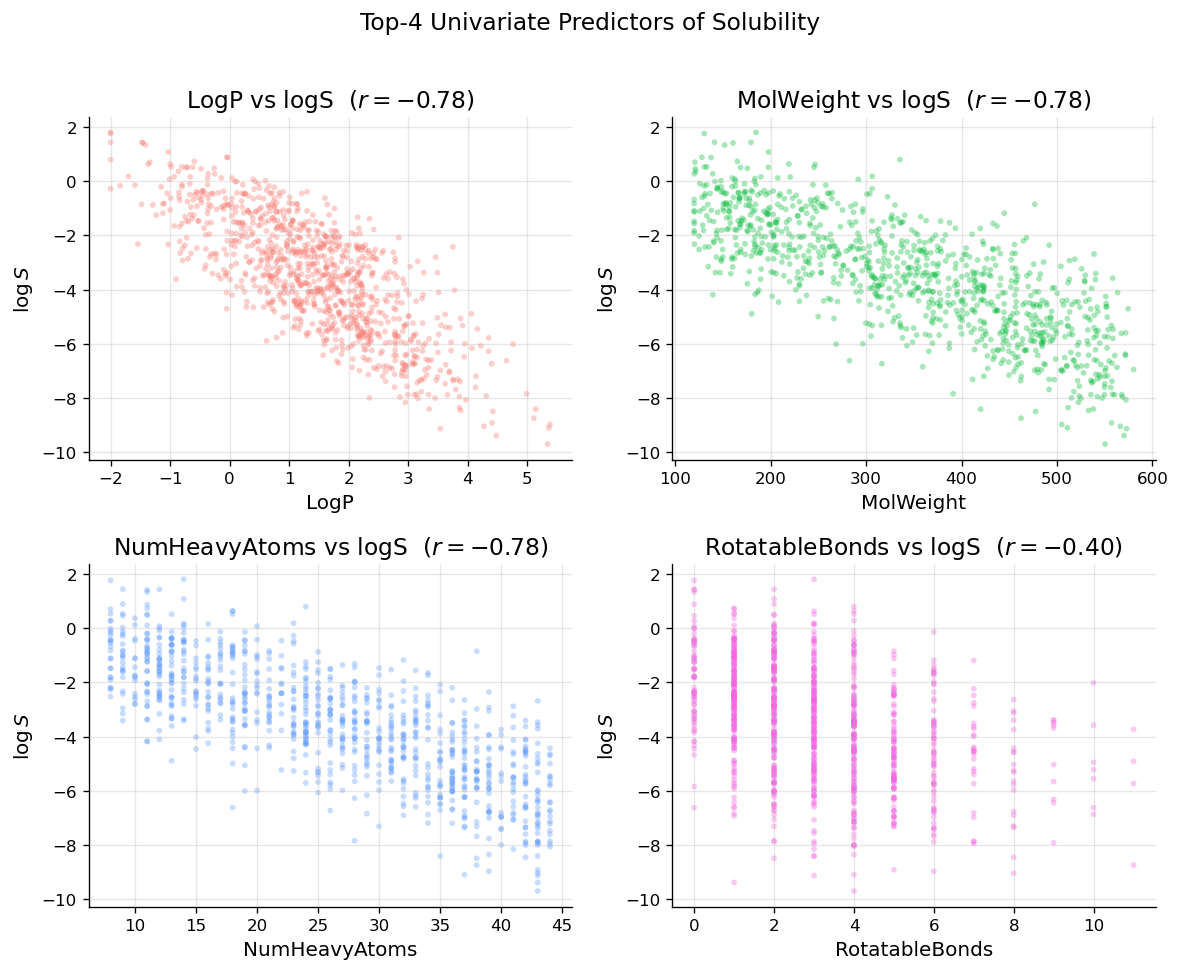

In [8]:
# Identify the 4 descriptors most correlated with logS
target_corr = corr["logS"].drop("logS").abs().sort_values(ascending=False)
top4 = target_corr.index[:4].tolist()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
colors = [SALMON, EMERALD, PERIWINKLE, ORCHID]

for ax, feat, col in zip(axes.ravel(), top4, colors):
    ax.scatter(df[feat], df["logS"], alpha=0.35, s=12, color=col, edgecolors="none")
    r_val = df[feat].corr(df["logS"])
    ax.set_xlabel(feat)
    ax.set_ylabel(r"$\log S$")
    ax.set_title(f"{feat} vs logS  ($r = {r_val:.2f}$)")

plt.suptitle("Top-4 Univariate Predictors of Solubility", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

As expected, **LogP** (hydrophobicity) and **MolWeight** show the strongest negative correlations with solubility. This is consistent with well-known chemistry: the old adage "like dissolves like" means that hydrophobic (high LogP) molecules dissolve poorly in water, and larger molecules have fewer favourable water interactions. The hydrogen bond descriptors (HBD, HBA, TPSA) show positive correlations — polar groups help a molecule interact with water.

---

## 5. Baseline Model — Regularised Linear Regression

We start with a **Ridge regression** baseline. As we saw in Module 11 Notebook 01 (Regularisation), Ridge regression adds an $\ell_2$ penalty to ordinary least squares:

$$
\hat{\boldsymbol{\beta}}_{\text{Ridge}} = \arg\min_{\boldsymbol{\beta}} \left\{ \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 + \alpha\,\|\boldsymbol{\beta}\|_2^2 \right\}
$$

With only 10 descriptors and 1,000 samples, regularisation is not strictly necessary for avoiding overfitting, but it is good practice and makes the model more numerically stable. We also fit a **Lasso** ($\ell_1$) model to see if it zeroes out any descriptors.

### 5.1 Train/Test Split and Model Fitting

We use an 80/20 split. The features are standardised (zero mean, unit variance) before fitting, as regularised models are sensitive to feature scales.

In [ ]:
# ── Train / test split ──
X = df[feature_cols].values
y = df["logS"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} samples,  Test: {X_test.shape[0]} samples")

# ── Ridge (alpha chosen by internal CV) ──
ridge_pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 50)))
ridge_pipe.fit(X_train, y_train)
ridge_alpha = ridge_pipe.named_steps["ridgecv"].alpha_

# ── Lasso (alpha chosen by internal CV) ──
lasso_pipe = make_pipeline(
    StandardScaler(),
    LassoCV(alphas=np.logspace(-4, 1, 50), cv=5, max_iter=10000, random_state=42),
)
lasso_pipe.fit(X_train, y_train)
lasso_alpha = lasso_pipe.named_steps["lassocv"].alpha_


# ── Evaluate ──
def evaluate(pipe, name, X_tr, y_tr, X_te, y_te):
    """Compute and print regression metrics."""
    y_pred_tr = pipe.predict(X_tr)
    y_pred_te = pipe.predict(X_te)
    results = {
        "Model": name,
        "Train RMSE": np.sqrt(mean_squared_error(y_tr, y_pred_tr)),
        "Test RMSE": np.sqrt(mean_squared_error(y_te, y_pred_te)),
        "Test MAE": mean_absolute_error(y_te, y_pred_te),
        "Test R^2": r2_score(y_te, y_pred_te),
    }
    return results


results = []
results.append(evaluate(ridge_pipe, "Ridge", X_train, y_train, X_test, y_test))
results.append(evaluate(lasso_pipe, "Lasso", X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results)
print(f"\nRidge alpha = {ridge_alpha:.4f}")
print(f"Lasso alpha = {lasso_alpha:.6f}\n")
print(results_df.round(4).to_string(index=False))

Train: 800 samples,  Test: 200 samples

Ridge alpha = 0.1600
Lasso alpha = 0.000100

Model  Train RMSE  Test RMSE  Test MAE  Test R^2
Ridge      0.4355     0.4503    0.3584    0.9529
Lasso      0.4355     0.4504    0.3584    0.9529


### 5.2 Predicted vs Actual Plot

The **predicted vs actual** scatter plot is the most common diagnostic in QSAR. Points lying along the identity line ($y = x$) indicate good predictions. Systematic deviations reveal model shortcomings.

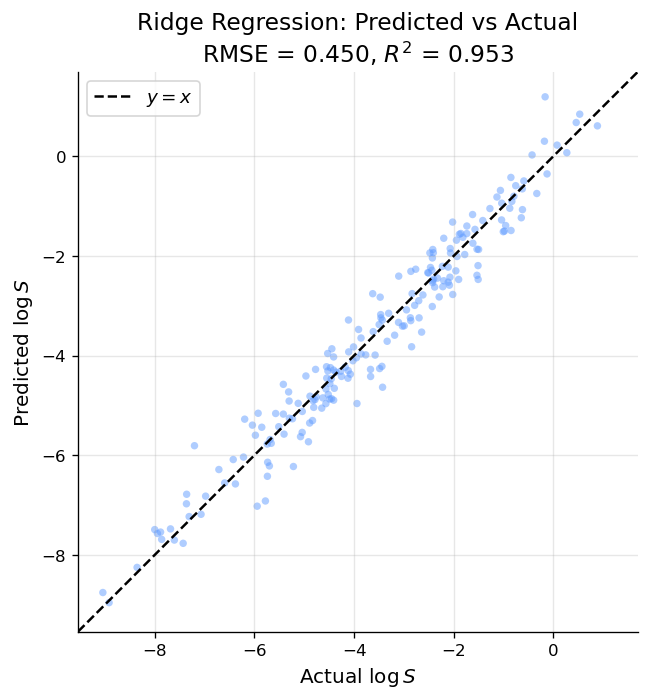

In [ ]:
y_pred_ridge = ridge_pipe.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_ridge, alpha=0.5, s=20, color=PERIWINKLE, edgecolors="none")

# Identity line
lo = min(y_test.min(), y_pred_ridge.min()) - 0.5
hi = max(y_test.max(), y_pred_ridge.max()) + 0.5
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5, label="$y = x$")

rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2 = r2_score(y_test, y_pred_ridge)
ax.set_xlabel(r"Actual $\log S$")
ax.set_ylabel(r"Predicted $\log S$")
ax.set_title(
    f"Ridge Regression: Predicted vs Actual\nRMSE = {rmse:.3f}, $R^2$ = {r2:.3f}"
)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

The Ridge model performs reasonably well. Solubility has a strong linear component driven by LogP and molecular weight, so a linear model captures much of the variance. However, there is room for improvement, especially in the tails of the distribution where nonlinear effects and descriptor interactions may matter.

---

## 6. Tree-Based Models

**Random Forests** and **Gradient Boosting Machines** (GBMs) consistently rank among the top performers on QSAR benchmarks. Their strengths for molecular property prediction include:

- **Automatic nonlinearity:** Trees model interactions and threshold effects without explicit feature engineering.
- **Robustness to feature scale:** No need for standardisation.
- **Feature importance:** Built-in measures tell us which descriptors drive predictions.

As we discussed in Module 11 Notebook 02 (Tree-Based Methods), a Random Forest averages many decorrelated trees (reducing variance), while Gradient Boosting builds trees sequentially (reducing bias). In QSAR practice, GBMs often have a slight edge in accuracy, while Random Forests are more robust to hyperparameter choices.

### 6.1 Fitting RF and GBM

In [ ]:
# ── Random Forest ──
rf = RandomForestRegressor(
    n_estimators=300, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
results.append(evaluate(rf, "Random Forest", X_train, y_train, X_test, y_test))

# ── Gradient Boosting ──
gbm = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42,
)
gbm.fit(X_train, y_train)
results.append(evaluate(gbm, "Gradient Boosting", X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results)
print(results_df.round(4).to_string(index=False))

            Model  Train RMSE  Test RMSE  Test MAE  Test R^2
            Ridge      0.4355     0.4503    0.3584    0.9529
            Lasso      0.4355     0.4504    0.3584    0.9529
    Random Forest      0.3786     0.5675    0.4545    0.9252
Gradient Boosting      0.0738     0.5543    0.4433    0.9287


### 6.2 Model Comparison

The bar chart below compares all four models on test RMSE. Lower is better.

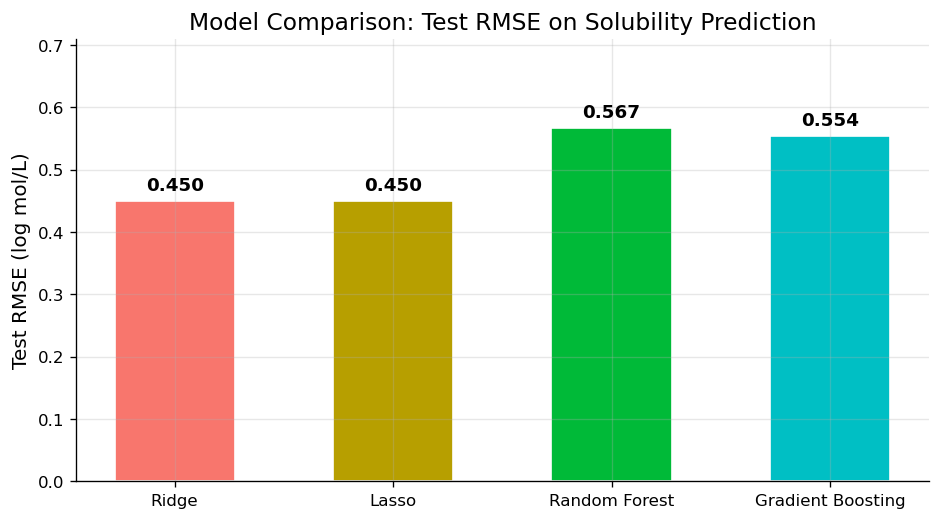

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))

model_names = results_df["Model"].tolist()
test_rmse = results_df["Test RMSE"].tolist()
bar_colors = [SALMON, GOLD, EMERALD, CYAN]

bars = ax.bar(model_names, test_rmse, color=bar_colors, edgecolor="white", width=0.55)
for bar, val in zip(bars, test_rmse):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.set_ylabel("Test RMSE (log mol/L)")
ax.set_title("Model Comparison: Test RMSE on Solubility Prediction")
ax.set_ylim(0, max(test_rmse) * 1.25)
plt.tight_layout()
plt.show()

### 6.3 Feature Importance

One of the most valuable outputs of a Random Forest is its **feature importance** ranking. For regression, the importance of a feature is measured by the total reduction in impurity (variance) that the feature achieves across all trees. This tells us which molecular descriptors are most predictive of solubility.

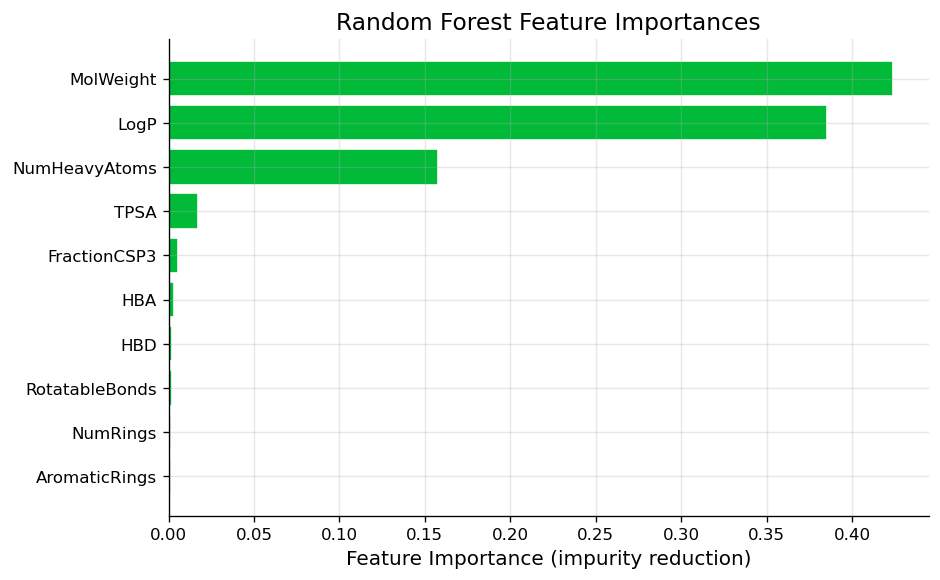

In [ ]:
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    [feature_cols[i] for i in sorted_idx],
    importances[sorted_idx],
    color=EMERALD,
    edgecolor="white",
)
ax.set_xlabel("Feature Importance (impurity reduction)")
ax.set_title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

As anticipated, **LogP** and **MolWeight** dominate the importance ranking. This is consistent with decades of QSAR research and with chemical intuition:

- **LogP** directly measures hydrophobicity, the primary thermodynamic driver of poor aqueous solubility.
- **MolWeight** is a proxy for molecular size; larger molecules have more crystal-packing energy to overcome when dissolving.

The fact that a data-driven model independently rediscovers what chemists have known for decades is a good sign — it means the model is learning *real* structure–property relationships, not just noise.

---

## 7. Cross-Validation Strategy

### 7.1 Why Random Splitting Can Be Optimistic

In standard ML, a random train/test split is usually fine. In QSAR, there is a subtlety: molecules are not independent samples drawn i.i.d. from some population. Molecules that are structurally similar (e.g., a drug and its close analog differing by one methyl group) will have similar descriptor values and similar properties. If both end up in the training set or are split across train and test, the model's apparent performance is inflated because it is partly "memorising" chemical series rather than learning generalisable structure–property relationships.

More rigorous splitting strategies used in practice include:

- **Scaffold splitting:** Group molecules by their core scaffold (ring system). Entire scaffolds go into either train or test, ensuring the model is tested on structurally novel chemical matter.
- **Temporal splitting:** Train on molecules published before a cutoff date, test on newer ones. This simulates the real use case of predicting properties of *future* molecules.
- **Cluster splitting:** Cluster molecules by fingerprint similarity, split at the cluster level.

These strategies consistently show **lower test performance** than random splitting, which means random-split results are optimistic estimates of real-world predictive power. This is a critical point for anyone deploying QSAR models in production.

### 7.2 K-Fold Cross-Validation

For our synthetic dataset (where we do not have scaffold information), we use standard 5-fold CV as a reasonable estimate. We report the distribution of test RMSE across folds for each model. This gives us a sense of both the average performance and its **variability**, which is essential for understanding model reliability.

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=ridge_alpha)),
    "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=lasso_alpha, max_iter=10000)),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        min_samples_leaf=5,
        subsample=0.8,
        random_state=42,
    ),
}

cv_results = {}
for name, model in models.items():
    # cross_val_score returns scores; for RMSE we use neg_mean_squared_error
    scores = cross_val_score(
        model, X, y, cv=kf, scoring="neg_mean_squared_error", n_jobs=-1
    )
    rmses = np.sqrt(-scores)
    cv_results[name] = rmses
    print(f"{name:20s}  RMSE = {rmses.mean():.4f} +/- {rmses.std():.4f}")

Ridge                 RMSE = 0.4443 +/- 0.0099
Lasso                 RMSE = 0.4443 +/- 0.0099
Random Forest         RMSE = 0.5679 +/- 0.0354
Gradient Boosting     RMSE = 0.5368 +/- 0.0244


The boxplot below visualises the distribution of fold-level RMSE values for each model. Compact boxes indicate stable performance; long whiskers suggest sensitivity to the particular train/test partition.

C:\Users\Alexander_Timmer\AppData\Local\Temp\ipykernel_27056\1581441200.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


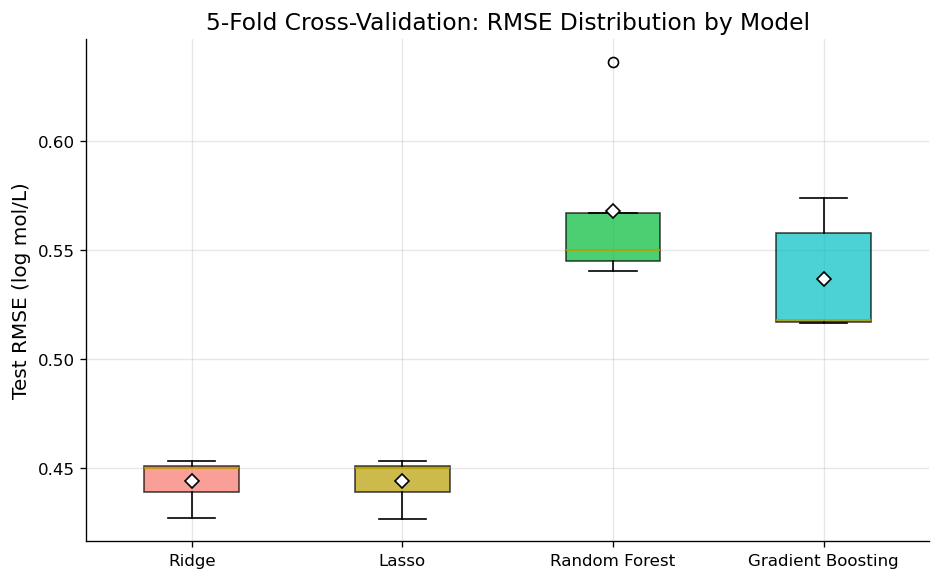

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bp_data = [cv_results[name] for name in models]
bp = ax.boxplot(
    bp_data,
    labels=list(models.keys()),
    patch_artist=True,
    widths=0.45,
    showmeans=True,
    meanprops=dict(
        marker="D", markerfacecolor="white", markeredgecolor="black", markersize=6
    ),
)

for patch, color in zip(bp["boxes"], [SALMON, GOLD, EMERALD, CYAN]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Test RMSE (log mol/L)")
ax.set_title("5-Fold Cross-Validation: RMSE Distribution by Model")
plt.tight_layout()
plt.show()

The ensemble methods (Random Forest, Gradient Boosting) typically show both lower median RMSE and tighter spread across folds, confirming their advantage for this type of tabular regression task. This is a common finding in QSAR benchmarks.

---

## 8. Applicability Domain

### 8.1 Why Applicability Domain Matters

A QSAR model is a statistical model. Like any regression, it should **not** be trusted when extrapolating far beyond its training data. In chemistry, this is formalised as the **applicability domain (AD)** — the region of chemical (descriptor) space where the model's predictions are considered reliable.

The importance of AD is codified in regulatory guidelines. The OECD Principles for the Validation of QSAR Models (2004) explicitly state that a QSAR prediction is only valid if the query molecule falls within the model's applicability domain. In drug discovery, deploying a model outside its AD can lead to costly false positives — synthesising and testing molecules that the model was never equipped to handle.

### 8.2 Leverage-Based Applicability Domain

One classical approach defines the AD using the **leverage** (hat value) from linear regression theory. For a new molecule with descriptor vector $\mathbf{x}_i$ (after centering and scaling), its leverage is:

$$
h_i = \mathbf{x}_i^\top (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{x}_i
$$

where $\mathbf{X}$ is the training descriptor matrix. The leverage measures how far $\mathbf{x}_i$ is from the centroid of the training set in descriptor space, weighted by the covariance structure. A high leverage means the molecule is in a region of chemical space that is poorly covered by training data.

The conventional warning threshold is:

$$
h^* = \frac{3(p + 1)}{n}
$$

where $p$ is the number of descriptors and $n$ is the number of training samples. Molecules with $h_i > h^*$ are flagged as potentially outside the applicability domain.

### 8.3 The Williams Plot

The **Williams plot** combines leverage with the standardised residual to give a two-dimensional diagnostic:

- **$x$-axis:** Leverage $h_i$ (distance from training centroid).
- **$y$-axis:** Standardised residual $r_i = (y_i - \hat{y}_i) / \hat{\sigma}$ (prediction error).

The plot is divided into four quadrants by the threshold lines $h^*$ and $\pm 3$ (three standard deviations). The quadrants have the following interpretation:

| Quadrant                   | Leverage | Residual | Interpretation                                   |
|----------------------------|----------|----------|--------------------------------------------------|
| **Bottom-left / Top-left** | Low      | Any      | Within AD, normal predictions                    |
| **Bottom-right**           | High     | Small    | Influential but well-predicted ("good leverage") |
| **Top-right**              | High     | Large    | **Outside AD and poorly predicted — unreliable** |

Molecules in the top-right quadrant are the most problematic: the model is extrapolating *and* getting it wrong.

In [16]:
# ── Compute leverage and standardised residuals for Ridge model ──
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Hat matrix: H = X (X'X)^{-1} X'
XtX_inv = np.linalg.inv(X_train_sc.T @ X_train_sc)

# Leverage for test set
h_test = np.array([x @ XtX_inv @ x for x in X_test_sc])

# Standardised residuals
residuals = y_test - y_pred_ridge
sigma_hat = np.std(residuals, ddof=1)
std_residuals = residuals / sigma_hat

# Threshold
p = X_train.shape[1]
n_train = X_train.shape[0]
h_star = 3 * (p + 1) / n_train

# Classify points
outside_ad = (h_test > h_star) & (np.abs(std_residuals) > 3)
high_leverage = (h_test > h_star) & (np.abs(std_residuals) <= 3)
high_residual = (h_test <= h_star) & (np.abs(std_residuals) > 3)
inside_ad = ~outside_ad & ~high_leverage & ~high_residual

print(f"Leverage threshold h* = 3(p+1)/n = 3({p}+1)/{n_train} = {h_star:.4f}")
print(f"\nMolecules inside AD:          {inside_ad.sum()}")
print(f"High leverage, well-predicted: {high_leverage.sum()}")
print(f"High residual, low leverage:   {high_residual.sum()}")
print(f"Outside AD (high h + high r):  {outside_ad.sum()}")

Leverage threshold h* = 3(p+1)/n = 3(10+1)/800 = 0.0413

Molecules inside AD:          198
High leverage, well-predicted: 0
High residual, low leverage:   2
Outside AD (high h + high r):  0


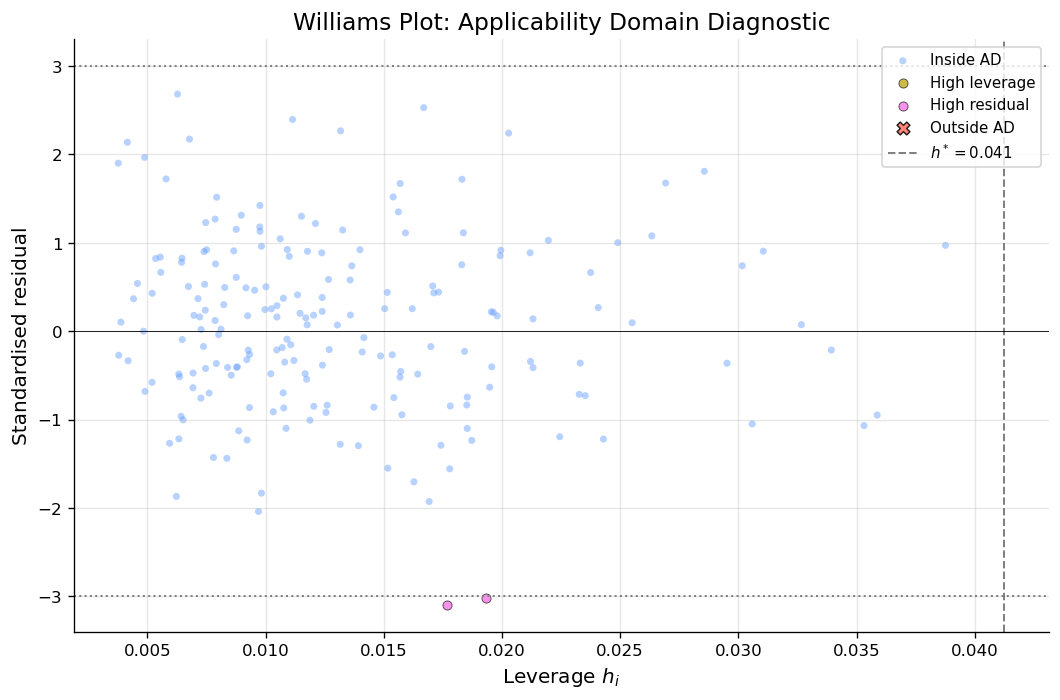

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    h_test[inside_ad],
    std_residuals[inside_ad],
    alpha=0.45,
    s=18,
    color=PERIWINKLE,
    edgecolors="none",
    label="Inside AD",
)
ax.scatter(
    h_test[high_leverage],
    std_residuals[high_leverage],
    alpha=0.7,
    s=30,
    color=GOLD,
    edgecolors="black",
    linewidths=0.5,
    label="High leverage",
)
ax.scatter(
    h_test[high_residual],
    std_residuals[high_residual],
    alpha=0.7,
    s=30,
    color=ORCHID,
    edgecolors="black",
    linewidths=0.5,
    label="High residual",
)
ax.scatter(
    h_test[outside_ad],
    std_residuals[outside_ad],
    alpha=0.9,
    s=60,
    color=SALMON,
    edgecolors="black",
    linewidths=0.8,
    marker="X",
    label="Outside AD",
    zorder=5,
)

# Threshold lines
ax.axvline(h_star, color="grey", ls="--", lw=1.2, label=f"$h^* = {h_star:.3f}$")
ax.axhline(3, color="grey", ls=":", lw=1.2)
ax.axhline(-3, color="grey", ls=":", lw=1.2)
ax.axhline(0, color="black", lw=0.5)

ax.set_xlabel("Leverage $h_i$")
ax.set_ylabel("Standardised residual")
ax.set_title("Williams Plot: Applicability Domain Diagnostic")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

The Williams plot shows that the vast majority of test molecules fall within the applicability domain (low leverage, small residuals). A small number of molecules have high leverage — these are structurally unusual relative to the training set. Among those, the ones with *also* large residuals (top-right quadrant, red crosses) are predictions the model should *not* be trusted on.

In a real drug discovery campaign, molecules flagged as outside the AD would either be deprioritised or flagged for experimental measurement rather than relying on the model prediction. This kind of **uncertainty-aware deployment** is a hallmark of responsible QSAR practice.

---

## 9. From Prediction to Drug Discovery

We have built and evaluated QSAR models for a single property (aqueous solubility) on a clean dataset with pre-computed descriptors. Real-world molecular property prediction is considerably more complex, but the statistical foundations are the same. Let us briefly survey how QSAR fits into the broader landscape.

### 9.1 Virtual Screening

The primary use of QSAR in drug discovery is **virtual screening**: computationally scoring large libraries of molecules (millions to billions) to identify the most promising candidates for synthesis and experimental testing. A typical workflow:

1. **Define the target property** (e.g., predicted binding affinity to a disease-relevant protein).
2. **Train a QSAR model** on known active and inactive compounds.
3. **Score a virtual library** of candidate molecules.
4. **Rank and filter** by predicted activity, solubility, toxicity, and other ADME properties.
5. **Synthesise and test** only the top candidates (typically a few hundred out of millions).

This process can reduce experimental costs by orders of magnitude. The key insight is that QSAR models do not need to be perfect — they just need to be *better than random selection* at the ranking task.

### 9.2 Multi-Task and Multi-Property Models

In practice, a drug candidate must satisfy multiple property constraints simultaneously: high potency, low toxicity, adequate solubility, good permeability, metabolic stability, and so on. **Multi-task models** predict several properties at once, sharing information across related endpoints. This is especially valuable when individual datasets are small — a common situation in drug discovery where experimental data is expensive to generate.

From a statistical perspective, multi-task learning is a form of **regularisation through shared structure**: the model is constrained to use a common representation for related tasks, which reduces overfitting on any single task.

### 9.3 Modern Representations: Graph Neural Networks

The descriptor-based approach we used in this notebook treats each molecule as a fixed-length vector. Modern approaches increasingly represent molecules as **graphs** (atoms = nodes, bonds = edges) and use **graph neural networks (GNNs)** to learn molecular representations directly from structure:

$$
\mathbf{h}_v^{(k+1)} = \text{UPDATE}\!\left(\mathbf{h}_v^{(k)},\; \text{AGGREGATE}\!\left(\{\mathbf{h}_u^{(k)} : u \in \mathcal{N}(v)\}\right)\right)
$$

where $\mathbf{h}_v^{(k)}$ is the hidden representation of atom $v$ at layer $k$, and $\mathcal{N}(v)$ is its set of bonded neighbours. After several rounds of message passing, atom representations are pooled into a molecular representation and fed to a prediction head.

GNNs can learn task-specific representations rather than relying on pre-defined descriptors, and they have achieved state-of-the-art results on many molecular property benchmarks. However, the **statistical foundations remain the same**: we still need proper train/test splitting, cross-validation, regularisation, and uncertainty quantification. A GNN without proper evaluation is no more trustworthy than a linear model without proper evaluation.

### 9.4 The Enduring Importance of Statistical Foundations

Whether the model is a Ridge regression from the 1960s or a transformer-based molecular model from 2025, the core statistical questions are unchanged:

- **Is the model fitting signal or noise?** (Regularisation — Module 11, Notebook 01)
- **How will it perform on unseen data?** (Cross-validation, this notebook)
- **When should we trust its predictions?** (Applicability domain, uncertainty quantification)
- **Which features drive the predictions?** (Feature importance, interpretability)

These are the questions this course has been training you to answer. QSAR is simply one of the most impactful domains where these answers matter.

---

## Key Takeaways

1. **QSAR connects molecular structure to macroscopic properties** through a pipeline of representation, featurisation, and supervised learning. It is one of the oldest and most successful applications of statistical modelling.

2. **Molecular descriptors** (MW, LogP, HBD, HBA, TPSA, etc.) encode the physicochemical properties that govern behaviour. Good descriptors capture the underlying physics and are interpretable.

3. **Simple linear models are surprisingly effective** for well-studied properties like solubility, where the structure–property relationship has a strong linear component.

4. **Tree-based ensembles** (Random Forest, Gradient Boosting) typically outperform linear models by capturing nonlinear effects and descriptor interactions, and they provide built-in feature importance.

5. **Cross-validation strategy matters.** Random splitting overestimates real-world performance. Domain-aware splits (scaffold, temporal, cluster) give more honest estimates.

6. **Applicability domain** defines where a model's predictions are trustworthy. The Williams plot is a simple but effective diagnostic combining leverage and residual magnitude.

7. **The statistical foundations are universal.** Regularisation, cross-validation, feature importance, and uncertainty quantification apply whether the model is linear regression or a graph neural network.

---

## References

- Hansch, C. & Fujita, T. (1964). $\rho$–$\sigma$–$\pi$ Analysis. A Method for the Correlation of Biological Activity and Chemical Structure. *Journal of the American Chemical Society*, 86(8), 1616–1626.
- Delaney, J. S. (2004). ESOL: Estimating Aqueous Solubility Directly from Molecular Structure. *Journal of Chemical Information and Computer Sciences*, 44(3), 1000–1005.
- Cherkasov, A. et al. (2014). QSAR Modeling: Where Have You Been? Where Are You Going To? *Journal of Medicinal Chemistry*, 57(12), 4977–5010.
- OECD (2004). Guidance Document on the Validation of (Quantitative) Structure-Activity Relationship Models. ENV/JM/MONO(2004)24.

In [18]:
cfg.save_gifs(clean=True)

  No new GIFs to save.
